# **01: Data Exploration**

## **Objective**
Analyze the raw energy demand dataset to identify missing values, seasonality patterns, outliers, and data distributions to decide on preprocessing measures.

## **Dataset Info**
* **Source:** UCI Machine Learning Repository
* **Title:** Appliances Energy Prediction
* **Time Range:** 11th January 2016 - 27th May 2016
* **Primary Target Variable:** `Appliances` (Watt-hour consumed)

In [1]:
# Import relevant packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

## **Initial Inspection**
This section will inspect the dataset structure, statistics, characteristics and quality.

### Import dataset into pandas DataFrame

In [2]:
# Get parent address
PARENT_ADDRESS = Path(os.getcwd()).parent

# Import csv file
energy = pd.read_csv(f'{PARENT_ADDRESS}/data/raw/energydata_complete.csv')

### Inspect samples

In [3]:
energy.head(3)

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668


### Inspect dataset characteristics

In [4]:
# Print dataset info
energy.info()

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  str    
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9           19

### Check for Duplicated Index (date)

In [5]:
# Check for duplicated date, as this will serve as index
print(f'Number of Duplicated Date: {energy['date'].duplicated().sum()}')

Number of Duplicated Date: 0


> ### 💡 **Key Takeaways**
> 1. **No missing values found**
>
> 2. **Date column have unconventional data type**
> 
>       **Decision**: Convert it to 'datetime64'and set as index.
>
> 3. **No duplicated index**

### Decision execution

In [6]:
# Convert 'date' into datetime64 format
energy['date'] = energy['date'].astype('datetime64[s]')

# Set 'date' as index
energy = energy.set_index('date')

### Inspect changes

In [7]:
energy.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 19735 entries, 2016-01-11 17:00:00 to 2016-05-27 18:00:00
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Appliances   19735 non-null  int64  
 1   lights       19735 non-null  int64  
 2   T1           19735 non-null  float64
 3   RH_1         19735 non-null  float64
 4   T2           19735 non-null  float64
 5   RH_2         19735 non-null  float64
 6   T3           19735 non-null  float64
 7   RH_3         19735 non-null  float64
 8   T4           19735 non-null  float64
 9   RH_4         19735 non-null  float64
 10  T5           19735 non-null  float64
 11  RH_5         19735 non-null  float64
 12  T6           19735 non-null  float64
 13  RH_6         19735 non-null  float64
 14  T7           19735 non-null  float64
 15  RH_7         19735 non-null  float64
 16  T8           19735 non-null  float64
 17  RH_8         19735 non-null  float64
 18  T9           19735 non

## **Drop Irrelevant/Unused Features**
We'll drop the features related to the readings taken from Chievres Airport, as data recorded from miles away introduces undesired spatial lag. Furthemore, we already have an outdoor temperature and humidity reading from the wall sensor (T6, RH_6).

In [8]:
# Define unused columns
unused = [
    'T_out',
    'Press_mm_hg',
    'RH_out',
    'Windspeed',
    'Visibility',
    'Tdewpoint'
]

# Drop columns
energy = energy.drop(unused, axis = 1)

In [9]:
# Check modified dataset
energy.dtypes

Appliances      int64
lights          int64
T1            float64
RH_1          float64
T2            float64
RH_2          float64
T3            float64
RH_3          float64
T4            float64
RH_4          float64
T5            float64
RH_5          float64
T6            float64
RH_6          float64
T7            float64
RH_7          float64
T8            float64
RH_8          float64
T9            float64
RH_9          float64
rv1           float64
rv2           float64
dtype: object

## **Aggregate Features**
Currently, the dataset contains 28 attributes, which can be complex to analyze. Furthermore, heat and moisture diffuse across adjacent room, which means that placing 28 sensors in a single house might be excessive and expensive. Hence, feature aggregation seems appropriate here.

We'll first look at feature collinearity to decide on the proper grouping. For visibility purposes, we'll divide the heatmap by temperature and humidity features.

C:\Users\User\AppData\Local\Temp\ipykernel_19024\8214638.py:77: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


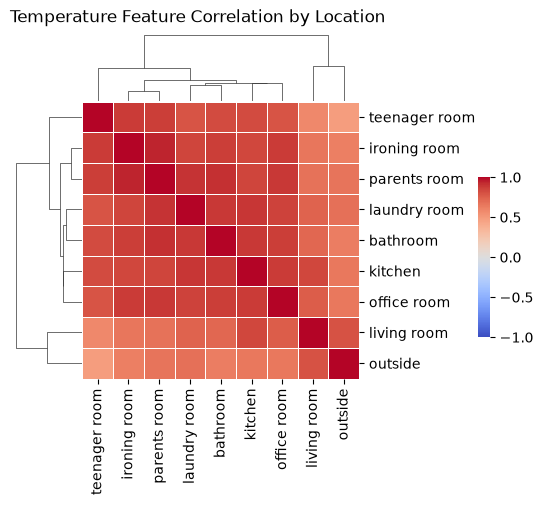

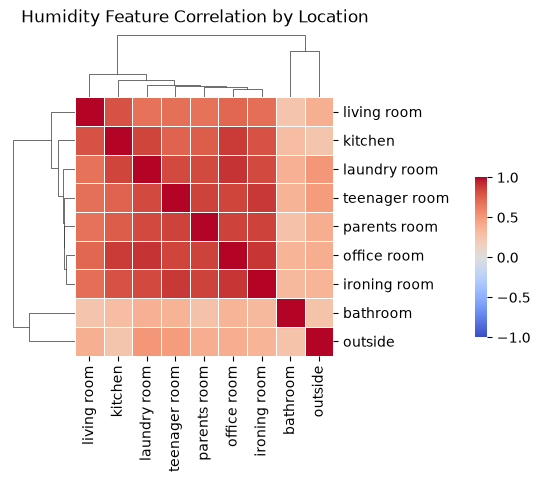

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define location sequence
loc = [
    "kitchen",
    "living room",
    "laundry room",
    "office room",
    "bathroom",
    "outside",
    "ironing room",
    "teenager room",
    "parents room",
]

# Initialize column names T1 - T9 and RH_1 - RH_9
temp_feature = [f"T{i+1}" for i in range(9)]
humid_feature = [f"RH_{i+1}" for i in range(9)]

# Calculate correlations
temp_corr = energy[temp_feature].corr(method="pearson")
humid_corr = energy[humid_feature].corr(method="pearson")

# Temperature Features
# ---
cg_temp = sns.clustermap(
    temp_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot=False,
    linewidths=0.5,
    figsize=(4, 4),
    cbar_pos=(1.2, 0.2, 0.03, 0.4),
)

# Reorder locations based on temperature dendrogram
temp_labels = [loc[i] for i in cg_temp.dendrogram_col.reordered_ind]

# Set X and Y labels
cg_temp.ax_heatmap.set_xticklabels(temp_labels, rotation=90)
cg_temp.ax_heatmap.set_yticklabels(temp_labels, rotation=0)

# Set title
cg_temp.fig.suptitle(
    "Temperature Feature Correlation by Location", y=1.02, fontsize=12
)


# Humidity Features
# ---
cg_humid = sns.clustermap(
    humid_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot=False,
    linewidths=0.5,
    figsize=(4, 4),
    cbar_pos=(1.2, 0.2, 0.03, 0.4),
)

# Reorder locations based on humidity dendrogram
humid_labels = [loc[i] for i in cg_humid.dendrogram_col.reordered_ind]

# Set X and Y labels
cg_humid.ax_heatmap.set_xticklabels(humid_labels, rotation=90)
cg_humid.ax_heatmap.set_yticklabels(humid_labels, rotation=0)

# Set title
cg_humid.fig.suptitle(
    "Humidity Feature Correlation by Location", y=1.02, fontsize=12
)

# Render both figures
plt.tight_layout()
plt.show()

Based on the heatmaps, this grouping seems appropriate:

### ```1. Main Indoor Areas``` 
> **Location**: kitchen, laundry room, ironing room, office room, teenager room, parents room

> **Justification**: High correlation across both temperature and humidity (signified by deep red color). Averaging eliminates severe multicollinearity with negligible loss of signal.

### ```2. Living Room```
> **Location**: Living room only

> **Justification**: Temperature transition similar towards outdoor condition

### ```3. Bathroom```
> **Location**: Bathroom only

> **Justification**: Humidity forms an isolated cluster with low overall correlation (signified by pale red color) to all other indoor rooms.

### ```4. Outdoor```
> **Location**: Outside only

> **Justification**: Low correlation with every other location, either in terms of temperature or humidity.